### Handin 1


# Info

Everything should be completed and approved in person. Groups are fine.

The objectives for this handin is:
* Playing with numpy.
* Plotting with Plotly (as a preparation for using dash (https://plotly.com/dash/) later on)
* Train a more complex model using the Fortuna Algorithm.
* Route planning for Knut Knut Transport AS. 

## How to solve?
There should be a comment/section stating the objective of a task.  
And there should be a commented section labeled # -- CODE --  
that shows where to put your code. For tasks that are not answered by code you can either write the answer  
as a markup cell or write it on a seperate piece of paper.

In [1]:
import numpy as np


# TASK: Create a numpy array containing the whole numbers between 1, 10 (inclusive)

# -- CODE --
a = np.arange(1, 11)


assert isinstance(a, np.ndarray)
assert np.isclose(a, [1,2,3,4,5,6,7,8,9,10]).all()
print("<ok>")

<ok>


In [2]:
# TASK: Reshape the array a so that it is a 2 by 4 array

a = np.array(range(0, 8))

# -- CODE --
a = a.reshape(2, 4)

assert( a.shape == (2,4) )
print("<ok>")

<ok>


In [3]:
# TASK: multiply all the numbers in a by 2.


a = np.array([[1,2,3,4], [5,6,7,8]])

# -- CODE --
a = a * 2

assert a.shape == (2,4)
assert a.sum() == 72
print("<ok>")

<ok>


In [4]:
# TASK:  create a numpy array b that contains the sum of each row (axis 1) in a 

a = np.array([[1,2,3,4], [5,6,7,8]])

# -- CODE --
b = a.sum(axis=1)

assert b.shape == (2,)
assert (b == [10, 26]).all()
print("<ok>")

<ok>


In [5]:
# TASK:  create a numpy array b that contains the mean value of each column (axis 0) in a 
a = np.array([[1,2,3,4], [1,2,3,8]])

# -- CODE --
b = a.mean(axis=0)

assert b.shape == (4,)
assert (b == [1, 2, 3, 6]).all()
print("<ok>")

<ok>


In [6]:
# TASK:  stack the arrays a, b and c into an array called s (vertically)
# s should be equal to s_true (hint, look at the numpy function vstack )


a = np.array([1, 3])
b = np.array([2, 4])
c = np.array([3, 5])

# -- CODE --
s = np.vstack((a, b, c))

s_true = np.array([[1, 3], [2, 4], [3, 5]])
assert (s_true == s).all()

print("<ok>")

<ok>


In [7]:
# TASK:  Flatten the array a into a 1d array called f (hint: numpy has a function named flatten)

a = np.random.randn(2,2,2)
print(a)

# -- CODE --
f = a.flatten()

print("-"*50)
print(f)
assert f.ndim == 1
print("<ok>")

[[[ 0.2821857   0.2737667 ]
  [-0.51004052 -0.94594346]]

 [[ 0.34585634 -0.07305182]
  [ 0.53555272  0.69767425]]]
--------------------------------------------------
[ 0.2821857   0.2737667  -0.51004052 -0.94594346  0.34585634 -0.07305182
  0.53555272  0.69767425]
<ok>


## Task 1 -- Plot functions and scatter plots using Plotly 

Change the code to perform the two following tasks:

(See Plotly: https://plotly.com/python/plotly-express/ for more info. If you for some reason cannot get plotly to work
just use another plotting framework).

**Line Plot)**

Plot the function f(x) = -0.69x^2 + 1.3x + 0.42 over the interval [0, 2.5], with 0.01 increments in x.

**Scatter Plot)**  

Plot the first 25 Fibbonachi numbers using a scatter plot.
(The example shows the first 5).




In [8]:
# installs plotly
!pip install plotly
!pip install jupyterlab ipywidgets

print("You may have to restart jupyter to see graphs in the notebook.")

You may have to restart jupyter to see graphs in the notebook.


In [9]:
import numpy as np
import plotly.express as px


# Change this code into the correct Line Plot

xs = np.array([1, 1.5, 2, 2.5, 6.0])
ys = np.array([1, 2, 3, 3.1, 2.5])


fig = px.line(x=xs, y=ys, title="Line Plot")
fig.update_layout(xaxis_range=[0,8], yaxis_range=[0,4])
fig.show()

# f(x)= -0.69*x^2+1.3*x+0.42  interval [0, 2.5] and 0.01 increment in x.
x = np.arange(0, 2.5, 0.01)
y = -0.69*x**2 + 1.3*x + 0.42

fig2 = px.line(x=x, y=y, title="Line Plot of f(x) = -0.69*x^2 + 1.3*x + 0.42")
fig2.update_layout(xaxis_range=[0,2.5], yaxis_range=[0,4])
fig2.show()

In [10]:
# Change this code into the correct Scatter Plot (please take care of the axis)

xs = np.array([1, 2, 3, 4, 5])
ys = np.array([1, 1, 2, 3, 5])


fig = px.scatter(x=xs, y=ys, title="Fibbonachi Scatter Plot")
fig.update_layout(xaxis_range=[0,6], yaxis_range=[0,10])
fig.show()

#plot the first 25 fibbonacci numbers in a scatter plot

fibonacci = [0,1]
for i in range (2,25):
    fibonacci.append(fibonacci[i-1] + fibonacci[i-2])

x = np.arange(0, 25)
y = np.array(fibonacci)

fig3 = px.scatter(x=x, y=y, title="Fibbonachi Scatter Plot 25 numbers")
fig3.update_layout(xaxis_range=[0,25])
fig3.show()


# Task 2 -- Numpy and curve fitting

Fill in the function get_2polynomal_from_3_points(). You are required to use the  
function: np.linalg.solve() for the actual computation, i.e. the task is mainly   
about shaping the input so it fits the np.linalg.solve() function. Note: dont use polyfit().

The function should return a 1d numpy array, with shape = (3,) in the format a, b,c.  
Such that ax^2 + bx + c = y, goes through the points p0, p1, p2

HINT: How should a matrix equation be formed, so solving it gives us the coefficients for a polynomial?

Limitations:
* There should be NO loops or ifs! (for/while/if). 
* Numpy functions that might come handy: reshape, hstack, flatten, ones



In [11]:
import numpy as np

def get_2polynomal_from_3_points(p0: np.array, p1: np.array, p2: np.array) -> np.array:
    # -- CODE --
    a = np.array([[p0[0]**2, p0[0], 1],
                  [p1[0]**2, p1[0], 1],
                  [p2[0]**2, p2[0], 1]])
    b = np.array([p0[1], p1[1], p2[1]])
    coeffs = np.linalg.solve(a, b)
    return coeffs

point0 = np.array([0.147, 0.596])
point1 = np.array([0.7, 0.992])
point2 = np.array([2.06, 0.17])

polynomial_coefficients = get_2polynomal_from_3_points(point0, point1, point2)
assert(polynomial_coefficients.shape[0] == 3 and polynomial_coefficients.ndim == 1)

print("Polynomial: {:2f}x^2 + {:.2f}x + {:.2f}".format(*polynomial_coefficients))


if not np.isclose(polynomial_coefficients[0], -0.69, atol=0.01):
    print("x^2 coeff is wrong (a), should be close to -0.69")
    
if not np.isclose(polynomial_coefficients[1], 1.3, atol=0.01):
    print("x coeff is wrong (b), should be close to 1.3")
    
if not np.isclose(polynomial_coefficients[2], 0.42, atol=0.01):
    print("Constant factor (c) is wrong, should be close to 0.42")
    
if np.isclose(polynomial_coefficients, [-0.69, 1.3, 0.42], atol=0.01).all():
    print("Correct polynomial found.")

Polynomial: -0.690280x^2 + 1.30x + 0.42
Correct polynomial found.


# Task 3 -- Simple random search

Find the triplet $a,b,c \in \{x \;|\; x \in \mathbb{Z} \text{ and } 450 > x > 0 \}$ 

Using a random search in the parameter space. Such that the following relations is satisfied: 

### a
$a = \begin{cases} c+11, & \text{if } b\text{ is even} \\ 2c-129, & \text{if } b\text{ is odd} \end{cases}$

### b
$b = (a \times c) \mod 2377$

### c
$c = \left( \sum\limits_{k=0}^{a-1} b - 7k \right) + 142$

**Also how many guesses were needed?**

Note that in math notation $\sum\limits_{k=1}^{5}k = 1+2+3+4+5$ 

Hint (to check if you got the right answer): The product $abc$ should be 255450 $\pm$ 20 
    
Can you find any optimizations besides multi-thread/multi-process?
Note: This HAS to be solved by a random search, not pen and paper.

optimizations can be to decompose the sumatory into multiplications,
use quicker bit operation to calculate if the number is even or odd,
check the conditions from simple to harder to past the bad numbers easily

In [12]:
import numpy as np

numbers = np.random.randint(1, 450, size=3)
a=numbers[0]
b=numbers[1]
c=numbers[2]

def check_numbers(a, b, c):
    if b != (a * c) % 2377:
        return False

    waiting_a = (c + 11) if (b & 1 == 0) else (2 * c - 129)
    if a != waiting_a:
        return False

    # The sum from 0 to a - 1 is the standard arithmetic series: a * (a - 1) // 2
    
    #waiting_c = a * b - (7 * a * (a - 1) // 2) + 142
    waiting_c = a * b - (7 * a * (a - 1) // 2) + 142
    if c != waiting_c:
        return False

    return True

#check the numbers until we find a valid combination
tries = 0
while not check_numbers(numbers[0], numbers[1], numbers[2]):
    numbers = np.random.randint(1, 450, size=3)
    tries += 1
#print one of the solutions
print(f"Found numbers: a={a}, b={b}, c={c}")
print(f"Number of tries: {tries}")
print  ("Check numbers: ",a*b*c," =255450+-20?")

Found numbers: a=107, b=277, c=138
Number of tries: 102793892
Check numbers:  4090182  =255450+-20?


# Task 4 -- Revisit the Fortuna Algorithm

Below is a implementation of Fortuna that uses fits linear function $f_{\theta} = a x + b$ where $\theta = \{a,b\}$ to a function $g(x)$.  
However, as is evidently from the graph, $g(x)$ is not a linear function.  

1) Change the code to instead use $f_{\theta}(x) = \sum\limits_{k=1}^{3} \Psi_k \sin(\gamma_k (x + \omega_k)) $.  
  Such that $|\theta| = 9$, where each parameter $c$ in $\theta$ is in $[-4. 4]$.  
That is, $f_{\theta}(x)$ is a sum of three sin terms. **Do not change the range of the sample\_theta function.**

3) However, it seems Fortuna (on average) struggles to find the optimal parameters $\theta$.  
Therefore you will have to innovate and change the Fortuna algorithm so that it faster finds "better solutions".
What changes did you make and **why** did you make them, and how did you measure how efficient these changes were?  
A excellent solution here will have an expected best loss of less than 5 using 100000 guesses. (take the average over 100 runs).
**But ANY improvment is sufficient to pass!**  

4) Using your newly made modified Fortuna Algorithm optimize the function: $h(x) = \mu - (\zeta sin(\kappa x) )  (\tau (x + \lambda))$ .  
The y values for this function can be found in the numpy array ys_h_1 (in the code below).  
Also test the values for ys_h_2. (the x is the same for all functions).

Does your new and improved Fortuna outperform the regular fortuna on this function as well? Why?   
**Remember to change your model to match $h(x)$**


4) [**Optional**] Develop a multiprocces implemention of the Fortuna algorithm using python's multiprocessing library (https://docs.python.org/3/library/multiprocessing.html).  
How are the speed ups? Are Fortuna really suited to parallel execution? (note: dont try multiprocess in a notebook - use a standalone file)




In [13]:
%%time
# the magic %%time has to be the first line in the cell, and reports the total exec time of the cell.

import random
import numpy as np
import plotly.express as px
import tqdm


def predict(x, theta):
    # change to sum of 3 sin() terms. 
    # use np.sin() and not math.sin().
    y = sum(theta[3*k] * np.sin(theta[3*k+1] * (x + theta[3*k+2])) for k in range(3))
    return y # this is the model


def sample_theta(size_of_theta):
    # Do NOT CHANGE.
    theta = np.random.uniform(-4, 4, size=size_of_theta)
    return theta


def get_loss(y_hat, ys):
    # No change needed, returns quadratic loss.
    loss = ((y_hat - ys)**2).sum()
    return loss

xs = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4])
ys = np.array([4.03, 4.19, 4.26, 4.25, 4.17, 4.03, 3.85, 3.63, 3.40, 3.16, 2.93, 2.72, 2.53, 2.39, 2.28, 2.21, 2.18, 2.19, 2.22, 2.27, 2.33, 2.39, 2.44, 2.45, 2.43, 2.36, 2.22, 2.02, 1.75, 1.41, 1.00, 0.52, -0.01, -0.60, -1.22, -1.86, -2.50, -3.13, -3.72, -4.27, -4.75, -5.15, -5.45, -5.65, -5.74, -5.70, -5.55, -5.29, -4.92, -4.44, -3.89, -3.26, -2.58, -1.86, -1.12, -0.39, 0.32, 0.98, 1.60, 2.14, 2.61, 2.99, 3.28, 3.47, 3.57])

# 
ys_h_1 = np.array([15.98, 21.42, 24.1, 23.87, 21.0, 16.11, 10.06, 3.79, -1.8, -6.01, -8.39, -8.82, -7.47, -4.77, -1.3, 2.31, 5.49, 7.81, 9.04, 9.18, 8.44, 7.15, 5.72, 4.54, 3.89, 3.9, 4.52, 5.54, 6.63, 7.39, 7.49, 6.7, 4.97, 2.44, -0.54, -3.48, -5.8, -6.98, -6.61, -4.51, -0.79, 4.2, 9.8, 15.21, 19.57, 22.09, 22.2, 19.63, 14.52, 7.41, -0.83, -9.07, -16.11, -20.83, -22.36, -20.27, -14.59, -5.91, 4.72, 15.9, 26.06, 33.69, 37.58, 36.94, 31.64])
ys_h_2 = np.array([[5.87, 5.83, 5.74, 5.62, 5.48, 16.58, 18.21, 18.49, 17.54, 15.54, 4.15, 3.9, 3.65, 3.42, 3.2, -1.9, -3.32, -3.97, -3.91, -3.27, 2.38, 2.36, 2.39, 2.46, 2.57, 2.2, 1.93, 1.22, 0.17, -1.06, 4.18, 4.59, 5.04, 5.52, 6.02, -1.49, 0.74, 3.55, 6.75, 10.06, 9.39, 9.95, 10.5, 11.02, 11.52, 16.0, 12.82, 8.47, 3.21, -2.62, 13.61, 13.76, 13.84, 13.84, 13.77, -24.16, -22.03, -17.9, -11.95, -4.55, 11.63, 10.99, 10.27, 9.47, 8.61]])

# change to the size of theta ( 9 ) (for h(x) how many parameters does it have?)
n_params = 9

best_loss = float('inf')
best_theta = sample_theta(n_params)

for _ in tqdm.tqdm(range(100000)): 
    curr_theta = sample_theta(n_params)
    y_hat = predict(xs, curr_theta)
    curr_loss = get_loss(y_hat, ys)

    if best_loss > curr_loss:
        best_loss = curr_loss
        best_theta = curr_theta
            
        
print("best loss:", best_loss)
print("theta:", best_theta)    
    
    
fig = px.line(x=xs, y=ys, title="f(x) vs Fortuna solution")
fig.add_scatter(x=xs, y=predict(xs, best_theta), mode='lines', name="y_hat")
fig.update_layout(xaxis_range=[xs.min(),xs.max()], yaxis_range=[-6,6])
fig.show()


# to get a solid estimate -> you should train at least 100 models and take the average performance.



100%|██████████| 100000/100000 [00:02<00:00, 46097.33it/s]


best loss: 36.00968627665037
theta: [ 2.37699411  2.0424133   2.58573977 -1.79507234 -2.09401389  0.45894027
  3.4019306  -0.92057022  3.19596356]


CPU times: total: 2.31 s
Wall time: 2.23 s


2) However, it seems Fortuna (on average) struggles to find the optimal parameters $\theta$.  
Therefore you will have to innovate and change the Fortuna algorithm so that it faster finds "better solutions".
What changes did you make and **why** did you make them, and how did you measure how efficient these changes were?  
A excellent solution here will have an expected best loss of less than 5 using 100000 guesses. (take the average over 100 runs).
**But ANY improvment is sufficient to pass!**  



### What changes did i make? and why?

I changed the generation of the theta parameters,

now we save the best theta and generates paramethers aroud that value.
New_theta = Best_theta + normal distribution (sigma).
so we try to guess near the solution.
the changes improve some tries but it looks like sometimes it get stuck in local minimuns or dont have enough precision to guess the correct paramethers.

Also after doing that i modified the sigma paramethers so we generate at first big changes with a big sigma. 
and a linear decay of the sigma to fit/finetune the model at the end steps.
with that we get better error scores.




### how did i measure the efficiency of the changes?

if we get a lower final error that means the changes are good.

In [14]:
%%time
# the magic %%time has to be the first line in the cell, and reports the total exec time of the cell.

import random
import numpy as np
import plotly.express as px
import tqdm


def predict(x, theta):
    # change to sum of 3 sin() terms. 
    # use np.sin() and not math.sin().
    y = sum(theta[3*k] * np.sin(theta[3*k+1] * (x + theta[3*k+2])) for k in range(3))
    return y # this is the model


def sample_theta(size_of_theta, best_theta=None, iteration=1, max_iters=100000):
    # linear decay of sigma, from 4.0 to 0.01
    progress = iteration / max_iters
    
    sigma = 4.0 - 3.99 * progress
    
    #print (f"Iteration {iteration}/{max_iters}, sigma: {sigma:.4f}")


    if best_theta is None:
        return np.random.uniform(-4, 4, size=size_of_theta)
    
    
    #we generate the noise with a normal distribution and add it tho the best theta
    noise = np.random.normal(0, sigma / 2.0, size=size_of_theta)
    theta = best_theta.copy()
    theta += noise
    
    # clip the values of theta to be between -4 and 4, to avoid extreme values
    return np.clip(theta, -4.0, 4.0)


def get_loss(y_hat, ys):
    # No change needed, returns quadratic loss.
    loss = ((y_hat - ys)**2).sum()
    return loss

xs = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4])
ys = np.array([4.03, 4.19, 4.26, 4.25, 4.17, 4.03, 3.85, 3.63, 3.40, 3.16, 2.93, 2.72, 2.53, 2.39, 2.28, 2.21, 2.18, 2.19, 2.22, 2.27, 2.33, 2.39, 2.44, 2.45, 2.43, 2.36, 2.22, 2.02, 1.75, 1.41, 1.00, 0.52, -0.01, -0.60, -1.22, -1.86, -2.50, -3.13, -3.72, -4.27, -4.75, -5.15, -5.45, -5.65, -5.74, -5.70, -5.55, -5.29, -4.92, -4.44, -3.89, -3.26, -2.58, -1.86, -1.12, -0.39, 0.32, 0.98, 1.60, 2.14, 2.61, 2.99, 3.28, 3.47, 3.57])

# 
ys_h_1 = np.array([15.98, 21.42, 24.1, 23.87, 21.0, 16.11, 10.06, 3.79, -1.8, -6.01, -8.39, -8.82, -7.47, -4.77, -1.3, 2.31, 5.49, 7.81, 9.04, 9.18, 8.44, 7.15, 5.72, 4.54, 3.89, 3.9, 4.52, 5.54, 6.63, 7.39, 7.49, 6.7, 4.97, 2.44, -0.54, -3.48, -5.8, -6.98, -6.61, -4.51, -0.79, 4.2, 9.8, 15.21, 19.57, 22.09, 22.2, 19.63, 14.52, 7.41, -0.83, -9.07, -16.11, -20.83, -22.36, -20.27, -14.59, -5.91, 4.72, 15.9, 26.06, 33.69, 37.58, 36.94, 31.64])
ys_h_2 = np.array([[5.87, 5.83, 5.74, 5.62, 5.48, 16.58, 18.21, 18.49, 17.54, 15.54, 4.15, 3.9, 3.65, 3.42, 3.2, -1.9, -3.32, -3.97, -3.91, -3.27, 2.38, 2.36, 2.39, 2.46, 2.57, 2.2, 1.93, 1.22, 0.17, -1.06, 4.18, 4.59, 5.04, 5.52, 6.02, -1.49, 0.74, 3.55, 6.75, 10.06, 9.39, 9.95, 10.5, 11.02, 11.52, 16.0, 12.82, 8.47, 3.21, -2.62, 13.61, 13.76, 13.84, 13.84, 13.77, -24.16, -22.03, -17.9, -11.95, -4.55, 11.63, 10.99, 10.27, 9.47, 8.61]])

# change to the size of theta ( 9 ) (for h(x) how many parameters does it have?)
n_params = 9
n_trials = 100
average_loss = 0.0

for i in range(n_trials):  # train 100 models and take the average
    best_loss = float('inf')
    best_theta = sample_theta(n_params, best_theta=None, iteration=1, max_iters=100000)

    for _ in tqdm.tqdm(range(100000)): 
        curr_theta = sample_theta(n_params, best_theta=best_theta, iteration=_+1, max_iters=100000)
        y_hat = predict(xs, curr_theta)
        curr_loss = get_loss(y_hat, ys)

        if best_loss > curr_loss:
            best_loss = curr_loss
            best_theta = curr_theta
    average_loss += best_loss
    print(f"Model {i+1}/{n_trials}: best loss: {best_loss}, theta: {best_theta}")
average_loss = average_loss/n_trials          
        
print("Average loss:", average_loss)
print("theta:", best_theta)    
    
    
fig = px.line(x=xs, y=ys, title="f(x) vs Fortuna PLus solution")
fig.add_scatter(x=xs, y=predict(xs, best_theta), mode='lines', name="y_hat")
fig.update_layout(xaxis_range=[xs.min(),xs.max()], yaxis_range=[-6,6])
fig.show()


# to get a solid estimate -> you should train at least 100 models and take the average performance.



100%|██████████| 100000/100000 [00:02<00:00, 38939.83it/s]


Model 1/100: best loss: 0.748446559985717, theta: [-3.84632389 -0.98962009 -0.80896329 -1.1223048  -1.21934275 -0.22575906
  2.1454638  -2.00492899 -1.59966724]


100%|██████████| 100000/100000 [00:02<00:00, 41395.18it/s]


Model 2/100: best loss: 1.602651160503852, theta: [ 3.6353814  -0.25340011 -3.9918586   2.52324128 -1.94337043  1.56306121
 -3.43721861 -1.31634822  3.50500461]


100%|██████████| 100000/100000 [00:02<00:00, 39363.62it/s]


...

100%|██████████| 100000/100000 [00:01<00:00, 71225.18it/s]


Model 99/100: best loss: 0.7071212899545877, theta: [ 3.525141   -0.95679015 -4.          1.38963256  1.20400825 -0.33991495
  2.19447672  1.97183707  0.04779961]


100%|██████████| 100000/100000 [00:01<00:00, 72144.62it/s]

Model 100/100: best loss: 0.3871846953384676, theta: [-2.96363555  0.87140524 -4.          2.49076392  1.93689951  0.07838225
 -1.92932105 -1.30937341 -0.90531317]
Average loss: 2.0438722970429395
theta: [-2.96363555  0.87140524 -4.          2.49076392  1.93689951  0.07838225
 -1.92932105 -1.30937341 -0.90531317]


CPU times: total: 3min 53s
Wall time: 3min 40s


3) Using your newly made modified Fortuna Algorithm optimize the function: $h(x) = \mu - (\zeta sin(\kappa x) )  (\tau (x + \lambda))$ .  
The y values for this function can be found in the numpy array ys_h_1 (in the code below).  
Also test the values for ys_h_2. (the x is the same for all functions).

Does your new and improved Fortuna outperform the regular fortuna on this function as well? Why?   
**Remember to change your model to match $h(x)$**

In [15]:
%%time
# the magic %%time has to be the first line in the cell, and reports the total exec time of the cell.

import random
import numpy as np
import plotly.express as px
import tqdm


def predict(x, theta):
    # change to sum of 3 sin() terms. 
    # use np.sin() and not math.sin().
    y = theta[0]-(theta[1]*np.sin(theta[2]*x))*(theta[3]*(x+theta[4])) 
    return y # this is the model


def sample_theta(size_of_theta, best_theta=None, iteration=1, max_iters=100000):
    # linear decay of sigma, from 4.0 to 0.01
    progress = iteration / max_iters
    
    sigma = 4.0 - 3.99 * progress
    sigma = 14.0 - 13.99 * progress
    #print (f"Iteration {iteration}/{max_iters}, sigma: {sigma:.4f}")


    if best_theta is None:
        return np.random.uniform(-4, 4, size=size_of_theta)
    
    
    #we generate the noise with a normal distribution and add it tho the best theta
    noise = np.random.normal(0, sigma / 2.0, size=size_of_theta)
    theta = best_theta.copy()
    theta += noise
    
    # clip the values of theta to be between -4 and 4, to avoid extreme values
    return np.clip(theta, -4.0, 4.0)


def get_loss(y_hat, ys):
    # No change needed, returns quadratic loss.
    loss = ((y_hat - ys)**2).sum()
    return loss

xs = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4])
ys = np.array([4.03, 4.19, 4.26, 4.25, 4.17, 4.03, 3.85, 3.63, 3.40, 3.16, 2.93, 2.72, 2.53, 2.39, 2.28, 2.21, 2.18, 2.19, 2.22, 2.27, 2.33, 2.39, 2.44, 2.45, 2.43, 2.36, 2.22, 2.02, 1.75, 1.41, 1.00, 0.52, -0.01, -0.60, -1.22, -1.86, -2.50, -3.13, -3.72, -4.27, -4.75, -5.15, -5.45, -5.65, -5.74, -5.70, -5.55, -5.29, -4.92, -4.44, -3.89, -3.26, -2.58, -1.86, -1.12, -0.39, 0.32, 0.98, 1.60, 2.14, 2.61, 2.99, 3.28, 3.47, 3.57])

# 
ys_h_1 = np.array([15.98, 21.42, 24.1, 23.87, 21.0, 16.11, 10.06, 3.79, -1.8, -6.01, -8.39, -8.82, -7.47, -4.77, -1.3, 2.31, 5.49, 7.81, 9.04, 9.18, 8.44, 7.15, 5.72, 4.54, 3.89, 3.9, 4.52, 5.54, 6.63, 7.39, 7.49, 6.7, 4.97, 2.44, -0.54, -3.48, -5.8, -6.98, -6.61, -4.51, -0.79, 4.2, 9.8, 15.21, 19.57, 22.09, 22.2, 19.63, 14.52, 7.41, -0.83, -9.07, -16.11, -20.83, -22.36, -20.27, -14.59, -5.91, 4.72, 15.9, 26.06, 33.69, 37.58, 36.94, 31.64])
ys_h_2 = np.array([5.87, 5.83, 5.74, 5.62, 5.48, 16.58, 18.21, 18.49, 17.54, 15.54, 4.15, 3.9, 3.65, 3.42, 3.2, -1.9, -3.32, -3.97, -3.91, -3.27, 2.38, 2.36, 2.39, 2.46, 2.57, 2.2, 1.93, 1.22, 0.17, -1.06, 4.18, 4.59, 5.04, 5.52, 6.02, -1.49, 0.74, 3.55, 6.75, 10.06, 9.39, 9.95, 10.5, 11.02, 11.52, 16.0, 12.82, 8.47, 3.21, -2.62, 13.61, 13.76, 13.84, 13.84, 13.77, -24.16, -22.03, -17.9, -11.95, -4.55, 11.63, 10.99, 10.27, 9.47, 8.61])

# change to the size of theta ( 9 ) (for h(x) how many parameters does it have?)
n_params = 5
average_loss = 0.0
n_trials = 10

for i in range(n_trials):  # train 100 models and take the average
    best_loss = float('inf')
    best_theta = sample_theta(n_params, best_theta=None, iteration=1, max_iters=100000)

    for _ in tqdm.tqdm(range(100000)): 
        curr_theta = sample_theta(n_params, best_theta=best_theta, iteration=_+1, max_iters=100000)
        y_hat = predict(xs, curr_theta)
        curr_loss = get_loss(y_hat, ys_h_1)

        if best_loss > curr_loss:
            best_loss = curr_loss
            best_theta = curr_theta
    average_loss += best_loss
    print(f"Model {i+1}/{n_trials}: best loss: {best_loss}, theta: {best_theta}")
average_loss = average_loss/n_trials           
        
print("Average loss:", average_loss)
print("theta:", best_theta)    
    
    
fig = px.line(x=xs, y=ys_h_1, title="ys_h_1 vs Fortuna PLus solution")
fig.add_scatter(x=xs, y=predict(xs, best_theta), mode='lines', name="y_hat")
fig.update_layout(xaxis_range=[xs.min(),xs.max()])
fig.show()


# to get a solid estimate -> you should train at least 100 models and take the average performance.



100%|██████████| 100000/100000 [00:00<00:00, 114892.89it/s]


Model 1/10: best loss: 0.47776269412593114, theta: [ 3.96565088 -3.14545686  3.69993776  2.88968534 -3.4902886 ]


100%|██████████| 100000/100000 [00:00<00:00, 114002.51it/s]


Model 2/10: best loss: 0.12405651748657927, theta: [ 3.94407033  3.73259189  3.70002843 -2.44172133 -3.49907366]


100%|██████████| 100000/100000 [00:00<00:00, 111968.29it/s]


...

100%|██████████| 100000/100000 [00:01<00:00, 67255.03it/s]


Model 9/10: best loss: 0.9061096611501613, theta: [ 3.98702031 -3.70352294 -3.70077076 -2.45013172 -3.49316272]


100%|██████████| 100000/100000 [00:01<00:00, 67203.52it/s]

Model 10/10: best loss: 0.12137936938847779, theta: [ 3.89867016 -4.          3.70015105  2.27341725 -3.50088391]
Average loss: 0.33951770109931245
theta: [ 3.89867016 -4.          3.70015105  2.27341725 -3.50088391]


CPU times: total: 11.5 s
Wall time: 11.4 s


with normal fortuna

In [16]:
%%time
# the magic %%time has to be the first line in the cell, and reports the total exec time of the cell.

import random
import numpy as np
import plotly.express as px
import tqdm


def predict(x, theta):
    # change to sum of 3 sin() terms. 
    # use np.sin() and not math.sin().
    y = theta[0]-(theta[1]*np.sin(theta[2]*x))*(theta[3]*(x+theta[4]))
    return y # this is the model


def sample_theta(size_of_theta):
    # Do NOT CHANGE.
    theta = np.random.uniform(-4, 4, size=size_of_theta)
    return theta


def get_loss(y_hat, ys):
    # No change needed, returns quadratic loss.
    loss = ((y_hat - ys)**2).sum()
    return loss

xs = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4.0, 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5.0, 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6.0, 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7.0, 7.1, 7.2, 7.3, 7.4])
ys = np.array([4.03, 4.19, 4.26, 4.25, 4.17, 4.03, 3.85, 3.63, 3.40, 3.16, 2.93, 2.72, 2.53, 2.39, 2.28, 2.21, 2.18, 2.19, 2.22, 2.27, 2.33, 2.39, 2.44, 2.45, 2.43, 2.36, 2.22, 2.02, 1.75, 1.41, 1.00, 0.52, -0.01, -0.60, -1.22, -1.86, -2.50, -3.13, -3.72, -4.27, -4.75, -5.15, -5.45, -5.65, -5.74, -5.70, -5.55, -5.29, -4.92, -4.44, -3.89, -3.26, -2.58, -1.86, -1.12, -0.39, 0.32, 0.98, 1.60, 2.14, 2.61, 2.99, 3.28, 3.47, 3.57])

# 
ys_h_1 = np.array([15.98, 21.42, 24.1, 23.87, 21.0, 16.11, 10.06, 3.79, -1.8, -6.01, -8.39, -8.82, -7.47, -4.77, -1.3, 2.31, 5.49, 7.81, 9.04, 9.18, 8.44, 7.15, 5.72, 4.54, 3.89, 3.9, 4.52, 5.54, 6.63, 7.39, 7.49, 6.7, 4.97, 2.44, -0.54, -3.48, -5.8, -6.98, -6.61, -4.51, -0.79, 4.2, 9.8, 15.21, 19.57, 22.09, 22.2, 19.63, 14.52, 7.41, -0.83, -9.07, -16.11, -20.83, -22.36, -20.27, -14.59, -5.91, 4.72, 15.9, 26.06, 33.69, 37.58, 36.94, 31.64])
ys_h_2 = np.array([5.87, 5.83, 5.74, 5.62, 5.48, 16.58, 18.21, 18.49, 17.54, 15.54, 4.15, 3.9, 3.65, 3.42, 3.2, -1.9, -3.32, -3.97, -3.91, -3.27, 2.38, 2.36, 2.39, 2.46, 2.57, 2.2, 1.93, 1.22, 0.17, -1.06, 4.18, 4.59, 5.04, 5.52, 6.02, -1.49, 0.74, 3.55, 6.75, 10.06, 9.39, 9.95, 10.5, 11.02, 11.52, 16.0, 12.82, 8.47, 3.21, -2.62, 13.61, 13.76, 13.84, 13.84, 13.77, -24.16, -22.03, -17.9, -11.95, -4.55, 11.63, 10.99, 10.27, 9.47, 8.61])

# change to the size of theta ( 9 ) (for h(x) how many parameters does it have?)
n_params = 5

best_loss = float('inf')
best_theta = sample_theta(n_params)

for _ in tqdm.tqdm(range(100000)): 
    curr_theta = sample_theta(n_params)
    y_hat = predict(xs, curr_theta)
    curr_loss = get_loss(y_hat, ys_h_1)

    if best_loss > curr_loss:
        best_loss = curr_loss
        best_theta = curr_theta
            
        
print("best loss:", best_loss)
print("theta:", best_theta)    
    
    
fig = px.line(x=xs, y=ys_h_1, title="ys_h_1 vs Fortuna solution")
fig.add_scatter(x=xs, y=predict(xs, best_theta), mode='lines', name="y_hat")
fig.update_layout(xaxis_range=[xs.min(),xs.max()], )
fig.show()


# to get a solid estimate -> you should train at least 100 models and take the average performance.


  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [00:01<00:00, 84465.34it/s]

best loss: 396.82716139859764
theta: [ 3.15101417  3.1213348  -3.67838361  2.92800885 -3.77966387]


CPU times: total: 1.23 s
Wall time: 1.21 s


# Task 5 -- Fortuna For Decision Trees

Implement a Decision Tree for solving the XOR problem.   
Here: there are 2 real valued inputs, x0, x1  (found in xs).  

And the DT should take these two as input and predict an output: 0 or 1.   
The true answer can be found in ys_true.


In [17]:
import numpy as np
rng = np.random.default_rng(42)
n_examples = 40

xs = rng.uniform(size=(n_examples, 2))
#print (xs)
# make a true y
b = (xs>0.5).astype(int)
ys_true = np.logical_xor(b[:, 0], b[:, 1]).astype(int)

#print(ys_true)

##################################
# here you implement a Decision Tree that is built using the fortuna algorithm.
# The depth of the tree should be less than 4
# The DT should reach 100% accuracy.

def predict_tree(xs, theta):
    """
    theta has the following structure:
      - features to evaluate in each split: feat0, feat1, feat2 in {0, 1} (we evaluate the first or the second number?)
      - thresholds for the splits: t0, t1, t2 in (0, 1) 
      - predictions in the 4 leaves: leaf_00, leaf_01, leaf_10, leaf_11 in {0, 1} 
    """
    f0, f1, f2 = theta['feats']
    t0, t1, t2 = theta['thresholds']
    leaves = theta['leaves']  

    #  (Node 0)
    go_right_0 = xs[:, f0] >= t0

    preds = np.zeros(len(xs), dtype=int)

    # left (go_right_0 == False)
    left_mask = ~go_right_0
    if np.any(left_mask):
        go_right_1 = xs[left_mask, f1] >= t1
        preds[left_mask] = np.where(go_right_1, leaves[1], leaves[0])

    # right (go_right_0 == True)
    right_mask = go_right_0
    if np.any(right_mask):
        go_right_2 = xs[right_mask, f2] >= t2
        preds[right_mask] = np.where(go_right_2, leaves[3], leaves[2])

    return preds

def sample_tree_theta():
    return {
        'feats': np.random.choice([0, 1], size=3),
        'thresholds': np.random.uniform(0.0, 1.0, size=3),
        'leaves': np.random.choice([0, 1], size=4)
    }

# search untill we find a solution that reaches 100% accuracy
max_iterations = 2000000
found = False

for iteration in range(max_iterations):
    candidate_theta = sample_tree_theta()
    preds = predict_tree(xs, candidate_theta)
    
    # evaluate accuracy
    accuracy = np.mean(preds == ys_true)
    
    if accuracy == 1.0:
        print(f"Solution found in iteration {iteration + 1}!")
        print("Accuracy: 100%")
        print(f"Features split (root, left, right): {candidate_theta['feats']}")
        print(f"Thresholds: {np.round(candidate_theta['thresholds'], 4)}")
        print(f"Leaves: {candidate_theta['leaves']}")
        found = True
        break

if not found:
    print("Increase the number of iterations.")

Solution found in iteration 111095!
Accuracy: 100%
Features split (root, left, right): [0 1 1]
Thresholds: [0.4779 0.5066 0.4894]
Leaves: [0 1 1 0]


# Task 6 -- Best Route App

A company called Knut Knut Transport AS is using one of the 4 routes for delivery (see Pitch\_knutknut\_transport.pdf for more info).
* A -> C -> D  
* A -> C -> E  
* B -> C -> D  
* B -> C -> E  

They have discovered that they can transport the goods faster by picking the right route given 
only the depature time of the transport.

In the file "traffic.jsonl" on Canvas is the collected data up to the current point in time.
So far, they have just selected a route at random, now they want to implement a simple web-api
that can help the drivers select the best route. 

* Using the data found in traffic.jsonl, create a ML model that given an time (hour:min) can select the fastest route to travel. **Be sure to document in a google doc/word/notebook/... how YOU created your ML model.** The ML model should be trained using the Fortuna algorithm.

* Download the knut\_knut\_app.py found on canvas an implement the function: get\_the\_best\_route\_as\_a\_text\_informatic(dep\_hour, dep\_min) such that the web application works and gives a good estimated time.

* The CEO (Knut) want you to estimate how much time they can save from using this new app.
* Prepare a VERY short presentation (pdf) on the gains and tech behind the app (random subsample will present for the class)


Some hints:
* Look closely at the data using both numerical analysis and visual (plotting). 
* Use the python library datetime to handle time calculations. 
* Make sure the features are scaled in a way that make sense.
* Once you have a model working, use the python library pickle to save/load the model.

In [20]:
import os
print(os.listdir('.'))

['handin1', 'handin1_final.ipynb', 'project 2 (knut knut).rar', 'route_optimizer_app', 'traffic.jsonl']


In [21]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load dataset
data = []
with open("traffic.jsonl", "r") as f:
    for line in f:
        if line.strip():
            data.append(json.loads(line))

# Create DataFrame (easy to manipulate and analyze)
df = pd.DataFrame(data)

#to get the time in decimal format
def parse_time(t_str):
    t = datetime.strptime(t_str, "%H:%M")
    return t.hour + t.minute / 60.0

#to get duration in minutes
def calc_duration(row):
    t_dep = datetime.strptime(row['depature'], "%H:%M")
    t_arr = datetime.strptime(row['arrival'], "%H:%M")
    dur = (t_arr - t_dep).total_seconds() / 60.0
    # handle wrap-around if any
    if dur < 0:
        dur += 24 * 60
    return dur

df['dep_decimal'] = df['depature'].apply(parse_time)
df['duration_min'] = df.apply(calc_duration, axis=1)

print(df.head())
print(df.describe())
print(df['road'].value_counts())

      road depature arrival  dep_decimal  duration_min
0  B->C->E    13:17   15:25    13.283333         128.0
1  A->C->E    07:07   08:47     7.116667         100.0
2  A->C->E    07:59   09:32     7.983333          93.0
3  B->C->E    14:21   16:29    14.350000         128.0
4  B->C->D    10:09   11:13    10.150000          64.0
       dep_decimal  duration_min
count  1031.000000   1031.000000
mean     12.149176     99.556741
std       2.893703     19.076556
min       7.000000     50.000000
25%       9.641667     87.000000
50%      12.133333     98.000000
75%      14.716667    111.000000
max      16.983333    163.000000
road
A->C->E    263
B->C->D    259
B->C->E    257
A->C->D    252
Name: count, dtype: int64


In [ ]:
#we divide the data into 4 different routes, and sort them by departure time
route_A_C_E_data = df[df["road"] == "A->C->E"].sort_values("dep_decimal").copy()
route_A_C_D_data = df[df["road"] == "A->C->D"].sort_values("dep_decimal").copy()
route_B_C_D_data = df[df["road"] == "B->C->D"].sort_values("dep_decimal").copy()
route_B_C_E_data = df[df["road"] == "B->C->E"].sort_values("dep_decimal").copy()

# Divide B->C->D into the specified departure-time intervals
interval_labels = [
    "07:00-07:15", "07:16-08:15", "08:16-09:15",
    "09:16-10:15", "10:16-11:15", "11:16-12:15",
    "12:16-13:15", "13:16-14:15", "14:16-15:15",
    "15:16-16:15", "16:16-17:15"
]

#in decimal hours, the intervals are:
interval_edges = [7.0, 7.25] + [hour + 0.25 for hour in range(8, 18)]

route_B_C_D_data["time_interval"] = pd.cut(
    route_B_C_D_data["dep_decimal"],
    bins=interval_edges,
    labels=interval_labels,
    include_lowest=True,
    right=True
)

#split the data into sub dataframes based on the time intervals
route_B_C_D_intervals = {
    interval: group.copy()
    for interval, group in route_B_C_D_data.groupby(
        "time_interval", observed=False
    )
}

print(route_B_C_D_data.to_string())

route_B_C_E_data["time_interval"] = pd.cut(
    route_B_C_E_data["dep_decimal"],
    bins=interval_edges,
    labels=interval_labels,
    include_lowest=True,
    right=True
)

route_B_C_E_intervals = {
    interval: group.copy()
    for interval, group in route_B_C_E_data.groupby(
        "time_interval", observed=False
    )
}


print(route_B_C_E_data.to_string())


         road depature arrival  dep_decimal  duration_min time_interval
365   B->C->D    07:00   08:52     7.000000         112.0   07:00-07:15
539   B->C->D    07:01   08:53     7.016667         112.0   07:00-07:15
133   B->C->D    07:04   08:57     7.066667         113.0   07:00-07:15
253   B->C->D    07:10   08:56     7.166667         106.0   07:00-07:15
329   B->C->D    07:15   08:59     7.250000         104.0   07:00-07:15
821   B->C->D    07:19   09:54     7.316667         155.0   07:16-08:15
113   B->C->D    07:19   09:54     7.316667         155.0   07:16-08:15
868   B->C->D    07:21   09:54     7.350000         153.0   07:16-08:15
193   B->C->D    07:25   09:54     7.416667         149.0   07:16-08:15
110   B->C->D    07:31   09:53     7.516667         142.0   07:16-08:15
815   B->C->D    07:31   09:55     7.516667         144.0   07:16-08:15
938   B->C->D    07:33   09:55     7.550000         142.0   07:16-08:15
183   B->C->D    07:35   09:57     7.583333         142.0   07:1

B->C->D | 07:00-07:15: duration = -36.30 * time + 367.10
B->C->D | 07:16-08:15: duration = -67.64 * time + 651.50
B->C->D | 08:16-09:15: duration = -80.06 * time + 811.65
B->C->D | 09:16-10:15: duration = -79.88 * time + 872.11
B->C->D | 10:16-11:15: duration = -60.12 * time + 728.30
B->C->D | 11:16-12:15: duration = -59.07 * time + 776.71
B->C->D | 12:16-13:15: duration = -63.92 * time + 897.85
B->C->D | 13:16-14:15: duration = -47.59 * time + 738.65
B->C->D | 14:16-15:15: duration = -34.79 * time + 614.78
B->C->D | 15:16-16:15: duration = -43.84 * time + 812.27
B->C->D | 16:16-17:15: duration = -63.60 * time + 1194.87
B->C->E | 07:00-07:15: duration = -64.84 * time + 543.20
B->C->E | 07:16-08:15: duration = -57.99 * time + 552.48
B->C->E | 08:16-09:15: duration = -60.24 * time + 630.26
B->C->E | 09:16-10:15: duration = -59.41 * time + 682.54
B->C->E | 10:16-11:15: duration = -58.36 * time + 731.04
B->C->E | 11:16-12:15: duration = -63.81 * time + 852.59
B->C->E | 12:16-13:15: duratio

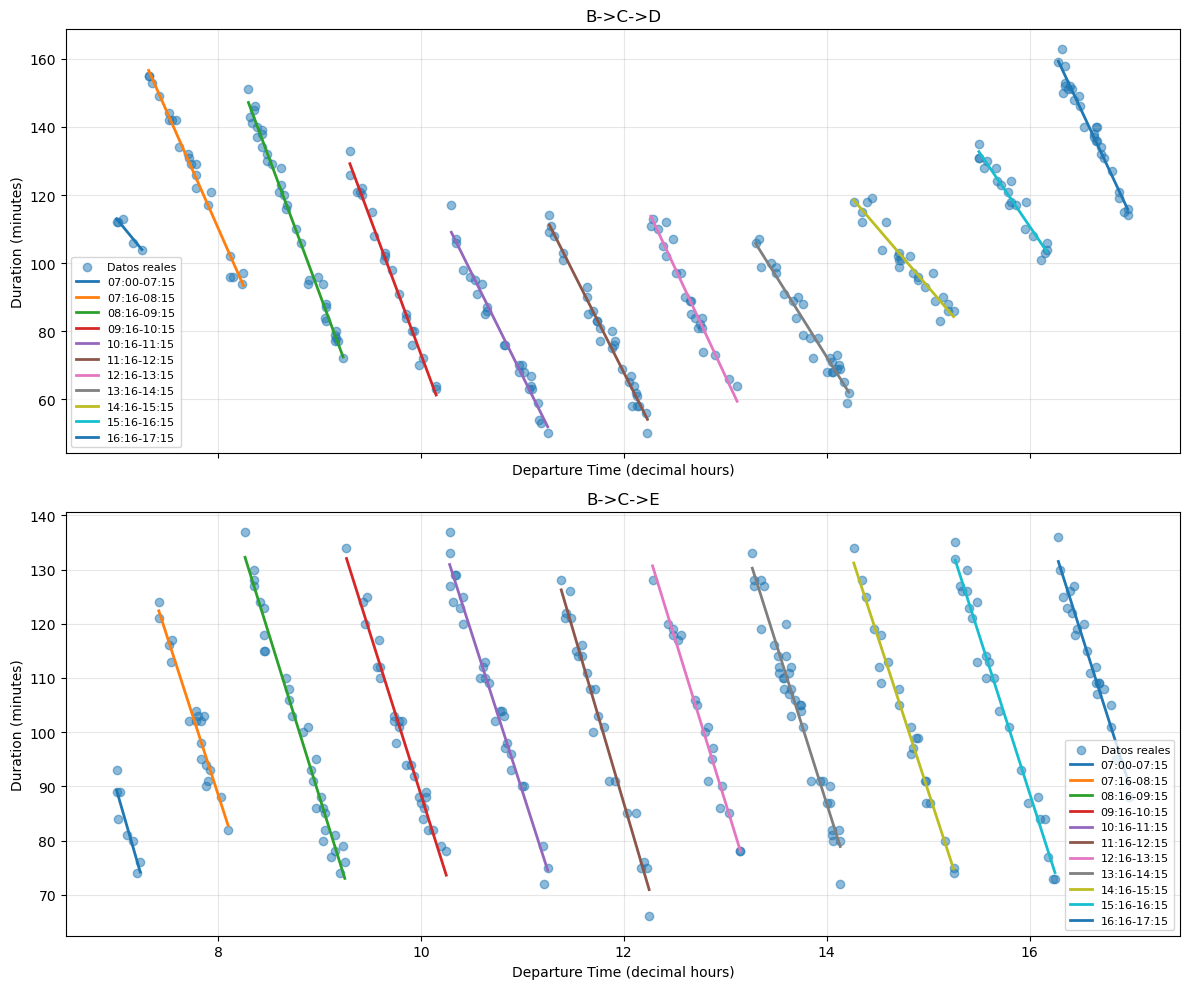

In [23]:
# interval linear regresion for the routes B->C->D y B->C->E

route_data = {
    "B->C->D": route_B_C_D_data,
    "B->C->E": route_B_C_E_data
}

linear_models = {}

for route, route_df in route_data.items():
    linear_models[route] = {}

    for interval, group in route_df.groupby("time_interval", observed=False):
        if len(group) < 2:
            continue

        x = group["dep_decimal"].to_numpy()
        y = group["duration_min"].to_numpy()

        slope, intercept = np.polyfit(x, y, 1)

        linear_models[route][str(interval)] = {
            "slope": slope,
            "intercept": intercept,
            "n": len(group)
        }

        print(
            f"{route} | {interval}: "
            f"duration = {slope:.2f} * time + {intercept:.2f}"
        )

# plotting the results
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for ax, (route, route_df) in zip(axes, route_data.items()):
    ax.scatter(
        route_df["dep_decimal"],
        route_df["duration_min"],
        alpha=0.5,
        label="Datos reales"
    )

    for interval, params in linear_models[route].items():
        group = route_df[
            route_df["time_interval"].astype(str) == interval
        ]

        x_line = np.linspace(
            group["dep_decimal"].min(),
            group["dep_decimal"].max(),
            50
        )
        y_line = (
            params["slope"] * x_line
            + params["intercept"]
        )

        ax.plot(x_line, y_line, linewidth=2, label=interval)

    ax.set_title(route)
    ax.set_xlabel("Departure Time (decimal hours)")
    ax.set_ylabel("Duration (minutes)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Model: duration = 0.06 · hour + 97.14
R² = 0.001


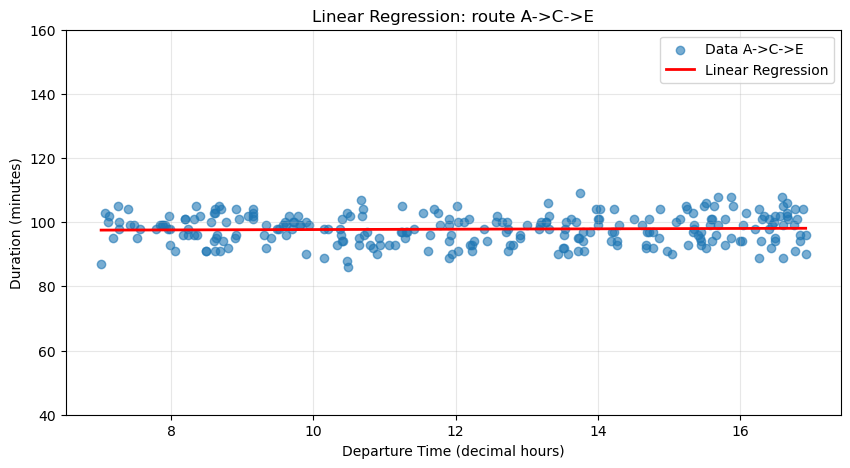

In [28]:
# linear regresion  A->C->E

route = route_A_C_E_data.dropna(subset=["dep_decimal", "duration_min"])

x = route["dep_decimal"].to_numpy()
y = route["duration_min"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Coeficiente de determinación R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print(f"Model: duration = {slope:.2f} · hour + {intercept:.2f}")
print(f"R² = {r2:.3f}")

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.6, label="Data A->C->E")
plt.plot(x_line, y_line, color="red", linewidth=2, label="Linear Regression")

plt.xlabel("Departure Time (decimal hours)")
plt.ylabel("Duration (minutes)")
plt.title("Linear Regression: route A->C->E")
plt.ylim(40, 160)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

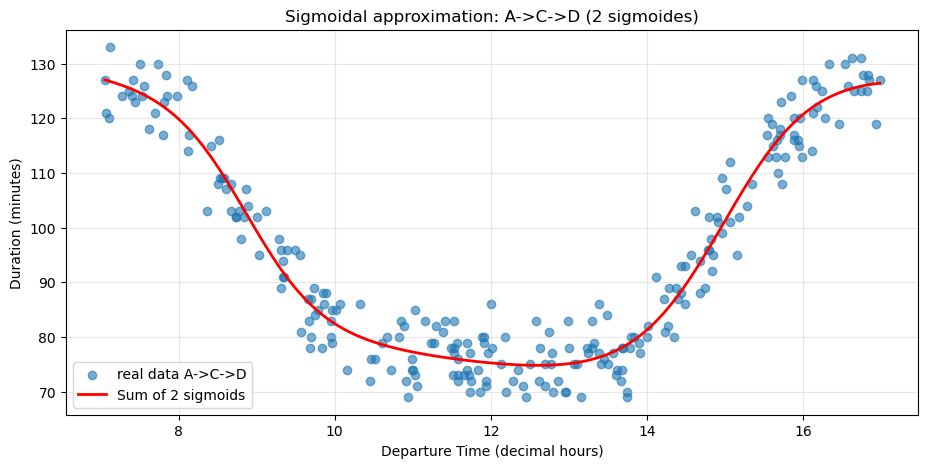

Adjusted parameters:
[141.20817103  -1.85776359 -44.14908839   2.03891318   8.86136463
  63.05060235   1.67262068  14.98018672]


In [27]:
from scipy.optimize import curve_fit

# sigmoidal approximation for A->C->D
route = route_A_C_D_data.dropna(subset=["dep_decimal", "duration_min"])

x_data = route["dep_decimal"].to_numpy()
y_data = route["duration_min"].to_numpy()


def sigmoid_sum(x, base, slope, *params):
    """
    params contiene grupos de tres valores:
    amplitud, pendiente y centro de cada sigmoide.
    """
    y = base + slope * x

    for i in range(0, len(params), 3):
        amplitude, steepness, center = params[i:i + 3]
        z = np.clip(steepness * (x - center), -700, 700)
        y += amplitude / (1 + np.exp(-z))

    return y


n_sigmoids = 2

initial_params = [
    100.0, 0.0,           # base, linear slope
    -80.0, 6.0, 8.0,      # sigmoide 1
     90.0, 4.0, 14.0      # sigmoide 2
]

lower_bounds = (
    [-np.inf, -np.inf] +
    [-300.0, 0.1, x_data.min()] * n_sigmoids
)

upper_bounds = (
    [np.inf, np.inf] +
    [300.0, 30.0, x_data.max()] * n_sigmoids
)

params_sigmoid, _ = curve_fit(
    sigmoid_sum,
    x_data,
    y_data,
    p0=initial_params,
    bounds=(lower_bounds, upper_bounds),
    maxfev=200000
)

x_sigmoid = np.linspace(x_data.min(), x_data.max(), 500)
y_sigmoid = sigmoid_sum(x_sigmoid, *params_sigmoid)

plt.figure(figsize=(11, 5))
plt.scatter(x_data, y_data, alpha=0.6, label="real data A->C->D")
plt.plot(x_sigmoid, y_sigmoid, color="red", linewidth=2,
         label="Sum of 2 sigmoids")
plt.xlabel("Departure Time (decimal hours)")
plt.ylabel("Duration (minutes)")
plt.title("Sigmoidal approximation: A->C->D (2 sigmoides)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print("Adjusted parameters:")
print(params_sigmoid)


In [26]:
base, slope, *params = params_sigmoid

print(f"f(x) = {base:.12f} + ({slope:.12f})x")

for i in range(0, len(params), 3):
    amplitude, steepness, center = params[i:i + 3]
    print(
        f" + ({amplitude:.12f}) / "
        f"(1 + exp(-({steepness:.12f}) * (x - {center:.12f})))"
    )

f(x) = 141.208171028210 + (-1.857763594676)x
 + (-44.149088388722) / (1 + exp(-(2.038913183625) * (x - 8.861364625860)))
 + (63.050602349853) / (1 + exp(-(1.672620676169) * (x - 14.980186722198)))


we have to multiply the sum of sigmoids by this 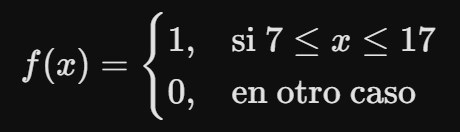

now we have all the functions for the four routes, and we can use them to predict the duration of a trip given the departure time and the route.

route B-C-D and B-C-E the table of ecuations is 
B->C->D | 07:00-07:15: duration = -36.30 * time + 367.10
B->C->D | 07:16-08:15: duration = -67.64 * time + 651.50
B->C->D | 08:16-09:15: duration = -80.06 * time + 811.65
B->C->D | 09:16-10:15: duration = -79.88 * time + 872.11
B->C->D | 10:16-11:15: duration = -60.12 * time + 728.30
B->C->D | 11:16-12:15: duration = -59.07 * time + 776.71
B->C->D | 12:16-13:15: duration = -63.92 * time + 897.85
B->C->D | 13:16-14:15: duration = -47.59 * time + 738.65
B->C->D | 14:16-15:15: duration = -34.79 * time + 614.78
B->C->D | 15:16-16:15: duration = -43.84 * time + 812.27
B->C->D | 16:16-17:15: duration = -63.60 * time + 1194.87
B->C->E | 07:00-07:15: duration = -64.84 * time + 543.20
B->C->E | 07:16-08:15: duration = -57.99 * time + 552.48
B->C->E | 08:16-09:15: duration = -60.24 * time + 630.26
B->C->E | 09:16-10:15: duration = -59.41 * time + 682.54
B->C->E | 10:16-11:15: duration = -58.36 * time + 731.04
B->C->E | 11:16-12:15: duration = -63.81 * time + 852.59
B->C->E | 12:16-13:15: duration = -60.75 * time + 876.87
B->C->E | 13:16-14:15: duration = -59.25 * time + 916.35
B->C->E | 14:16-15:15: duration = -57.37 * time + 949.71
B->C->E | 15:16-16:15: duration = -58.66 * time + 1027.28
B->C->E | 16:16-17:15: duration = -58.89 * time + 1090.40

for A-C-D we have this ecuation
f(x) = 141.208171028210 + (-1.857763594676)x
 + (-44.149088388722) / (1 + exp(-(2.038913183625) * (x - 8.861364625860)))
 + (63.050602349853) / (1 + exp(-(1.672620676169) * (x - 14.980186722198)))

 and for A-C-E we have f(x) = 98 min
 
 we need to do the app with flask that calculate the best route given an hour, and also says the time we save depending to the other routes.
 the only possible hours are between 7:00 and 17:00

EXTRA CONTENT 

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Crear la cuadrícula 2x2
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Route A->C->E", "Route A->C->D",
        "Route B->C->D", "Route B->C->E"
    )
)

# 2. Mapeo de datasets y su posición (fila, columna)
routes = [
    (route_A_C_E_data, 1, 1),
    (route_A_C_D_data, 1, 2),
    (route_B_C_D_data, 2, 1),
    (route_B_C_E_data, 2, 2)
]

for df, r, c in routes:
    fig.add_trace(
        go.Scatter(
            x=df["dep_decimal"],
            y=df["duration_min"],
            mode="markers",
            showlegend=False,
            hovertemplate="<b>Salida:</b> %{x:.2f}h<br><b>Duración:</b> %{y:.1f} min<extra></extra>"
        ),
        row=r, col=c
    )


# 3. Fijar el rango de Y (30 a 180) en los 4 subplots y estilos
fig.update_yaxes(range=[30, 180], title_text="Duration (minutes)")
fig.update_xaxes(title_text="Departure time (decimal hours)")
fig.update_layout(height=800, width=1000, template="plotly_white")

# Abre el gráfico interactivo en el navegador o notebook
fig.show()

In [ ]:
#print (route_B_C_E_data.to_string())
route_B_C_E_data.describe()


,dep_decimal,duration_min
count,257.000000,257.000000
mean,12.044617,103.334630
std,2.869680,17.003816
min,7.000000,66.000000
25%,9.600000,89.000000
50%,12.033333,104.000000
75%,14.466667,117.000000
max,16.983333,137.000000


the intervals are: 

(7-7:15)(7:16-8:15)(8:16-9:15)(9:16-10:15)(10:16-11:15)(11:16-12:15)(12:16-13:15)(13:16-14:15)(14:16-15:15)(15:16-16:15)(16:16-17:15)

now we can divide the B routes in segments to modelate them better.
(i took the last quicker data point as the threshold for the segments)
B->C->D INTERVALS


depature arrival  dep_decimal  duration_min
07:00   08:52     7.000000         112.0
07:15   08:59     7.250000         104.0


07:19   09:54     7.316667         155.0
08:15   09:52     8.250000          97.0


08:18   10:49     8.300000         151.0
09:14   10:26     9.233333          72.0


09:18   11:31     9.300000         133.0
10:09   11:12    10.150000          63.0


10:18   12:15    10.300000         117.0
11:15   12:05    11.250000          50.0


11:16   13:10    11.266667         114.0
12:14   13:04    12.233333          50.0


12:16   14:07    12.266667         111.0
13:07   14:11    13.116667          64.0


13:18   15:04    13.300000         106.0
14:13   15:15    14.216667          62.0


14:16   16:14    14.266667         118.0
15:15   16:41    15.250000          86.0


15:30   17:41    15.500000         131.0
16:10   17:56    16.166667         106.0


16:17   18:56    16.283333         159.0
16:58   18:54    16.966667         116.0

------------------------------------------------------

B->C->E INTERVALS


depature arrival  dep_decimal  duration_min
07:00   08:33     7.000000          93.0
07:14   08:30     7.233333          76.0


07:25   09:29     7.416667         124.0
08:06   09:28     8.100000          82.0


08:16   10:33     8.266667         137.0
09:15   10:31     9.250000          76.0


09:16   11:30     9.266667         134.0
10:15   11:33    10.250000          78.0


10:17   12:30    10.283333         133.0
11:15   12:30    11.250000          75.0


11:23   13:31    11.383333         128.0
12:15   13:21    12.250000          66.0


12:17   14:25    12.283333         128.0
13:09   14:27    13.150000          78.0


13:16   15:29    13.266667         133.0
14:08   15:20    14.133333          72.0


14:16   16:30    14.266667         134.0
15:15   16:30    15.250000          75.0


15:16   17:28    15.266667         132.0
16:15   17:28    16.250000          73.0


16:17   18:33    16.283333         136.0
16:59   18:27    16.983333          88.0


